In [160]:
num_files = 8  # Change this to the actual number of files to read

age_matrix_vec = []

FLAG = 2050

# FLAG = 2023

def load_age_matrices(FLAG):
    """
    Loads age matrices based on the specified FLAG value.
    
    Args:
        FLAG (int): Flag indicating which data to load (2050, 2023, or 0)
        
    Returns:
        list: List of age matrices
    """
    age_matrix_vec = []
    num_files = 8

    if FLAG == 2050:
        # Directory containing the binary files
        data_dir = "../../output/20250526_151118"

        # Read each binary file
        for i in range(8):
            filename = os.path.join(data_dir, f"forecast_matrix_{i}.bin")
            
            # Get file size to determine number of rows
            file_size = os.path.getsize(filename)
            num_rows = file_size // (27 * 4)  # 27 columns, 4 bytes per int32
            
            # Create numpy matrix of appropriate size
            matrix = np.zeros((num_rows, 27), dtype=np.int32)
            
            # Read binary data into matrix
            with open(filename, 'rb') as f:
                # Read all values at once into flattened array
                data = np.fromfile(f, dtype=np.int32)
                # Reshape into matrix
                matrix = data.reshape((num_rows, 27))
            
            age_matrix_vec.append(matrix)
        
        for idx in range(8):
            matrix = age_matrix_vec[idx]  # Extract the matrix
            # Check each row, and keep it if not all values are negative
            filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
            age_matrix_vec[idx] = filtered_matrix


    elif FLAG == 2023:
        path = "/Users/haolong/Documents/demos_v_matrix/output/"
        for i in range(num_files):
            # Create the filename dynamically
            filename = f"popu_matrix_{i}.csv"
            matrix = pd.read_csv(path + filename).to_numpy() # convert to numpy
            age_matrix_vec.append(matrix)

        for idx in range(8):
            matrix = age_matrix_vec[idx]  # Extract the matrix
            # Check each row, and keep it if not all values are negative
            filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
            age_matrix_vec[idx] = filtered_matrix

    elif FLAG == 0:
        # Create combined matrices for each index
        age_matrix_vec_2023 = load_age_matrices(2023)
        age_matrix_vec_2050 = load_age_matrices(2050)
        
        for i in range(8):
            # Get dimensions
            rows_2023 = age_matrix_vec_2023[i].shape[0]
            rows_2050 = age_matrix_vec_2050[i].shape[0]
            max_rows = rows_2050

            # Create empty matrix filled with -1
            combined = np.full((max_rows, 61), -1)

            # Fill left block with 2023 data
            combined[:rows_2023, :34] = age_matrix_vec_2023[i]

            # Fill right block with 2050 data
            combined[:rows_2050, 34:] = age_matrix_vec_2050[i]

            age_matrix_vec.append(combined)
            

    return age_matrix_vec

In [161]:
age_matrix_vec = load_age_matrices(2023)

## use differnet A input 

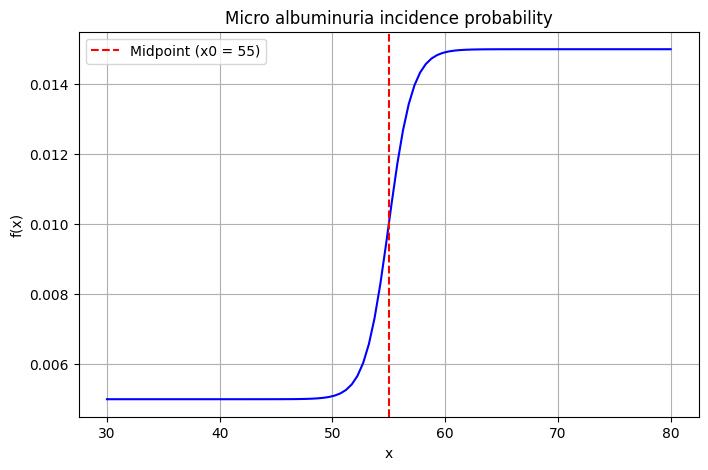

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Define the logistic function
def logistic_function(x, A=0.005, x0=55, k=0.95):
    L = A + 0.01
    return A + (L - A) / (1 + np.exp(-k * (x - x0)))


# Generate x values
x = np.linspace(30, 80, 100)  # Range centered around x0
y = logistic_function(x)

# Plot the function
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='b')

plt.axvline(x=55, linestyle='--', color='red', label="Midpoint (x0 = 55)")

# Labels and title
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Micro albuminuria incidence probability")
plt.legend()
plt.grid()

# Show the plot
plt.show()

In [290]:
# finally should be a 2* 8 * 21 * 55 shape 

# Initialize probability matrix with shape (2, 8, 21, 55)
# First dimension: state transitions (0->1, 1->2)
# Second dimension: 8 groups (gender-ethnicity combinations)
# Third dimension: 21 different A values
# Fourth dimension: Ages 20-74 (55 values)
prob_matrix = np.zeros((2, 8, 2, 55))
A_range = [0.001, 0.005]
for idx in range(8):
    for A_idx, A in enumerate(A_range):
        for x_idx, x in enumerate(range(20, 75)):
            prob = logistic_function(x, A)
            
            # store the prob in a matrix 
            prob_matrix[0,idx,A_idx,x_idx] = prob * coef[idx]

# for albu == 2
for idx in range(8):
    eth = map_eth(idx)
    gen = idx % 2
    for x_idx, x in enumerate(range(20,75)):
        if x >= 26:
            prob_2 = result[gen, eth, x - 26, 2] 
        else:
            prob_2 = 0
        prob_matrix[1,idx,:,x_idx] = prob_2 * coef[idx]



In [292]:
# Calculate probability of staying healthy (state a)

# Calculate probability of staying healthy
# Initialize probability matrices
healthy_prob = np.zeros((8, 2, 55))  # Shape: 8 groups x 2 A values x 55 ages
micro_albu = np.zeros((8, 2, 55))    # Shape: 8 groups x 2 A values x 55 ages

# Calculate probabilities for all groups
for idx in range(8):
    for A_idx, A in enumerate(A_range):
        for age_idx in range(55):  # age 20 to 74
            transition_prob = prob_matrix[0, idx, A_idx, age_idx]  # a → b
            
            if age_idx == 0:
                # For age 20, just use initial probability of staying healthy
                healthy_prob[idx, A_idx, age_idx] = 1 - transition_prob
            else:
                # For subsequent ages, multiply previous probability by probability of staying healthy
                healthy_prob[idx, A_idx, age_idx] = healthy_prob[idx, A_idx, age_idx-1] * (1 - transition_prob)

# Calculate probability of being in microalbuminuria (state b)
for idx in range(8):
    for A_idx, A in enumerate(A_range):
        prob_in_b = 0.0
        for age_idx in range(55):  # age 20 to 74
            if age_idx == 0:
                # For age 20, just use initial transition probability
                inflow = prob_matrix[0, idx, A_idx, age_idx]
            else:
                # Inflow from a → b in current age
                inflow = healthy_prob[idx, A_idx, age_idx-1] * prob_matrix[0, idx, A_idx, age_idx]
            
            # Surviving from previous b state (did not go to c)
            prob_in_b = prob_in_b * (1 - prob_matrix[1, idx, A_idx, age_idx]) + inflow
            
            # Store result
            micro_albu[idx, A_idx, age_idx] = prob_in_b



# Calculate micro albuminuria and healthy rates for each ethnicity and A value
for A_idx, A in [(0,-1), (1,1)]:
    total_counts = 0
    total_micro_counts = 0 
    total_healthy_counts = 0

    for i in range(8):
        # Get age counts from age matrix for this ethnicity
        age_counts = np.zeros(75-18)  # Vector to store counts for ages 18-74
        
        # Create dictionary to count ages
        age_dict = {}
        for age_val in age_matrix_vec[i][:,-34]: # - 34 means first column
            age_dict[age_val] = age_dict.get(age_val, 0) + 1
        
        # Convert dictionary counts to vector
        for age in range(18, 75):
            age_counts[age-18] = age_dict.get(age, 0)
        
        # Get micro albuminuria and healthy rates for this ethnicity
        micro_rates = micro_albu[i,A_idx]
        healthy_rates = healthy_prob[i,A_idx,:]
        
        micro_counts = micro_rates * age_counts[2:] # 2: means from age 20
        healthy_counts = healthy_rates * age_counts[2:]
        
        
        total_micro_counts += np.sum(micro_counts)
        total_healthy_counts += np.sum(healthy_counts)
        total_healthy_counts += np.sum(age_counts[:2])
        total_counts += np.sum(age_counts)

    micro_result = total_micro_counts / total_counts * 100
    healthy_result = total_healthy_counts / total_counts * 100
    macro_result = 100 - micro_result - healthy_result

    print(f"\nResults for A = {A}:")
    print(f"Total micro albuminuria rate: {micro_result:.2f}%")
    print(f"Total healthy rate: {healthy_result:.2f}%") 
    print(f"Total macro albuminuria rate: {macro_result:.2f}%")



Results for A = -1:
Total micro albuminuria rate: 3.06%
Total healthy rate: 96.54%
Total macro albuminuria rate: 0.40%

Results for A = 1:
Total micro albuminuria rate: 9.80%
Total healthy rate: 88.86%
Total macro albuminuria rate: 1.34%


## generate another simulation

albu_1_mat = np.where(random_vals < p0 + p1, np.where(random_vals < p1, 1, 2), 0)


0.7, 0.2, 0.1

In [279]:
accumulated_prob(ages_vector[mask], i, A_idx, 0)

array([0.986049  , 0.986049  , 0.986049  , 0.986049  , 0.986049  ,
       0.986049  , 0.986049  , 0.986049  , 0.986049  , 0.986049  ,
       0.97914666, 0.97914666, 0.97914666, 0.97914666, 0.97914666,
       0.97914666, 0.97914666, 0.97914666, 0.97914666, 0.97229263,
       0.97229263, 0.97229263, 0.97229263, 0.97229263, 0.97229263,
       0.97229263, 0.97229263, 0.97229263, 0.97229263, 0.97229263,
       0.97229263, 0.97229263, 0.97229263, 0.96548658, 0.96548658,
       0.96548658, 0.96548658, 0.96548658, 0.96548658, 0.96548658,
       0.96548658, 0.96548658, 0.96548658, 0.96548658, 0.96548658,
       0.96548658, 0.95872818, 0.95872818, 0.95872818, 0.95872818,
       0.95872818, 0.95872818, 0.95872818, 0.95872818, 0.95872818,
       0.95872818, 0.95872818, 0.95872818, 0.95872818, 0.95201708,
       0.95201708, 0.95201708, 0.95201708, 0.95201708, 0.95201708,
       0.95201708, 0.95201708, 0.95201708, 0.95201708, 0.95201708,
       0.95201708, 0.95201708, 0.95201708, 0.95201708, 0.94535

In [283]:
total_counts

3473151

In [293]:
# Calculate micro albuminuria and healthy rates for each ethnicity and A value
for A_idx, A in [(0,-1), (1,1)]:
    total_counts = 0
    total_micro_counts = 0 
    total_healthy_counts = 0

    for i in range(8):
        # Get ages vector and create mask for valid age range
        ages_vector = age_matrix_vec[i][:,-34]
        mask = (ages_vector > 20) & (ages_vector < 75)  # Fixed boolean operation
        
        # Get probabilities for valid ages
        p0 = accumulated_prob(ages_vector[mask], i, A_idx, 0)  # Healthy prob
        p1 = accumulated_prob(ages_vector[mask], i, A_idx, 1)  # Micro prob
        
        # Generate random values and classify outcomes
        random_vals = np.random.rand(len(ages_vector[mask]))
        albu_1_mat = np.zeros(len(ages_vector[mask]), dtype=int)
        albu_1_mat = np.where(random_vals < p0 + p1, np.where(random_vals < p0, 0, 1), 2)
        
        # Count outcomes
        micro_counts = np.sum(albu_1_mat == 1)
        healthy_counts = np.sum(albu_1_mat == 0)
        age_counts = len(ages_vector[mask])
        
        # Accumulate totals
        total_micro_counts += micro_counts
        total_healthy_counts += healthy_counts
        total_counts += age_counts

    # Calculate percentages
    micro_result = total_micro_counts / total_counts * 100
    healthy_result = total_healthy_counts / total_counts * 100
    macro_result = 100 - micro_result - healthy_result

    print(f"\nResults for A = {A}:")
    print(f"Total micro albuminuria rate: {micro_result:.2f}%")
    print(f"Total healthy rate: {healthy_result:.2f}%") 
    print(f"Total macro albuminuria rate: {macro_result:.2f}%")


Results for A = -1:
Total micro albuminuria rate: 3.77%
Total healthy rate: 96.23%
Total macro albuminuria rate: 0.00%

Results for A = 1:
Total micro albuminuria rate: 11.84%
Total healthy rate: 88.15%
Total macro albuminuria rate: 0.00%


### 0 - 85, 85+ 
### for 85+, assume their avg age is 90

In [228]:
# 20 - 90 
# Initialize probability matrix with shape (2, 8, 2, 71)
# First dimension: state transitions (0->1, 1->2)
# Second dimension: 8 groups (gender-ethnicity combinations)
# Third dimension: 2 different A values
# Fourth dimension: Ages 20-90 (71 values)



In [278]:
# Calculate micro albuminuria and healthy rates for each ethnicity and A value
for A_idx, A in [(0,-1), (1,1)]:
    total_counts = 0
    total_micro_counts = 0 
    total_healthy_counts = 0

    for i in range(8):
        # Get ages vector and create mask for valid age range
        ages_vector = age_matrix_vec[i][:,-34]
        mask = (ages_vector > 20) & (ages_vector < 75)  # Fixed boolean operation
        
        # Get probabilities for valid ages
        p0 = accumulated_prob(ages_vector[mask], i, A_idx, 0)  # Healthy prob
        p1 = accumulated_prob(ages_vector[mask], i, A_idx, 1)  # Micro prob
        
        # Generate random values and classify outcomes
        random_vals = np.random.rand(len(ages_vector[mask]))
        albu_1_mat = np.zeros(len(ages_vector[mask]), dtype=int)
        albu_1_mat = np.where(random_vals < p0 + p1, np.where(random_vals < p1, 1, 2), 0)
        
        # Count outcomes
        micro_counts = np.sum(albu_1_mat == 1)
        healthy_counts = np.sum(albu_1_mat == 0)
        age_counts = len(ages_vector[mask])
        
        # Accumulate totals
        total_micro_counts += micro_counts
        total_healthy_counts += healthy_counts
        total_counts += age_counts

    # Calculate percentages
    micro_result = total_micro_counts / total_counts * 100
    healthy_result = total_healthy_counts / total_counts * 100
    macro_result = 100 - micro_result - healthy_result

    print(f"\nResults for A = {A}:")
    print(f"Total micro albuminuria rate: {micro_result:.2f}%")
    print(f"Total healthy rate: {healthy_result:.2f}%") 
    print(f"Total macro albuminuria rate: {macro_result:.2f}%")


Results for A = -1:
Total micro albuminuria rate: 3.76%
Total healthy rate: 0.00%
Total macro albuminuria rate: 96.24%

Results for A = 1:
Total micro albuminuria rate: 12.02%
Total healthy rate: 0.00%
Total macro albuminuria rate: 87.98%


In [272]:
# Example usage of accumulated_prob function
ages = np.arange(20, 75)  # Creates array [20, 21, ..., 75]
i = 0  # Example ethnicity index
A_idx = 0  # Example A index (A=-1)
level = 1  # Get micro albuminuria probabilities

# Get probabilities for all ages
example_probs = accumulated_prob(ages, i, A_idx, level)



print("Example probabilities for ages 20-75:")

print("\nFirst few probabilities:")
for age, prob in list(zip(ages, example_probs))[:5]:
    print(f"Age {age}: {prob:.4f}")
print("...")
print("\nLast few probabilities:") 
for age, prob in list(zip(ages, example_probs))[-5:]:
    print(f"Age {age}: {prob:.4f}")

# Assert that micro_albu[i,A_idx] matches example_probs
assert np.allclose(micro_albu[i,A_idx], example_probs), "micro_albu[i,A_idx] does not match example_probs"





Example probabilities for ages 20-75:

First few probabilities:
Age 20: 0.0009
Age 21: 0.0018
Age 22: 0.0027
Age 23: 0.0036
Age 24: 0.0045
...

Last few probabilities:
Age 70: 0.1698
Age 71: 0.1781
Age 72: 0.1862
Age 73: 0.1943
Age 74: 0.1991


In [273]:

# Get healthy probabilities for all ages
example_healthy_probs = accumulated_prob(ages, i, A_idx, level=0)

# Assert that healthy_prob[i,A_idx] matches example_healthy_probs
assert np.allclose(healthy_prob[i,A_idx], example_healthy_probs), "healthy_prob[i,A_idx] does not match example_healthy_probs"

array([0.0009    , 0.00179919, 0.00269757, 0.00359514, 0.00449191,
       0.00538786, 0.00628302, 0.00717736, 0.0080709 , 0.00896364,
       0.00985557, 0.0107467 , 0.01163703, 0.01252655, 0.01341528,
       0.01430321, 0.01519033, 0.01607666, 0.0169622 , 0.01784693,
       0.01873087, 0.01961403, 0.02049642, 0.02137807, 0.02225908,
       0.02313971, 0.02402059, 0.02490336, 0.02579229, 0.02669831,
       0.02764942, 0.02871602, 0.03006818, 0.03207689, 0.03537747,
       0.04058643, 0.04767653, 0.05598939, 0.06487051, 0.07394414,
       0.0830406 , 0.09209098, 0.10106872, 0.10996409, 0.1187739 ,
       0.12749744, 0.13613499, 0.14468717, 0.15315473, 0.16153849,
       0.16983925, 0.17805784, 0.18619507, 0.19425173, 0.19908704])

## testing

In [277]:
# Calculate micro albuminuria and healthy rates for each ethnicity and A value
for A_idx, A in [(0,-1), (1,1)]:
    total_counts = 0
    total_micro_counts = 0 
    total_healthy_counts = 0

    for i in range(8):
        # Get ages vector and create mask for valid age range
        ages_vector = age_matrix_vec[i][:,-34]
        mask = (ages_vector > 20) & (ages_vector < 85)  # Fixed boolean operation
        
        # Get probabilities for valid ages
        p0 = accumulated_prob(ages_vector[mask], i, A_idx, 0)  # Healthy prob
        p1 = accumulated_prob(ages_vector[mask], i, A_idx, 1)  # Micro prob
        
        # Generate random values and classify outcomes
        random_vals = np.random.rand(len(ages_vector[mask]))
        albu_1_mat = np.zeros(len(ages_vector[mask]), dtype=int)
        albu_1_mat = np.where(random_vals < p0 + p1, np.where(random_vals < p1, 1, 2), 0)
        
        # Count outcomes
        micro_counts = np.sum(albu_1_mat == 1)
        healthy_counts = np.sum(albu_1_mat == 0)
        age_counts = len(ages_vector[mask])
        
        # Accumulate totals
        total_micro_counts += micro_counts
        total_healthy_counts += healthy_counts
        total_counts += age_counts

    # Calculate percentages
    micro_result = total_micro_counts / total_counts * 100
    healthy_result = total_healthy_counts / total_counts * 100
    macro_result = 100 - micro_result - healthy_result

    print(f"\nResults for A = {A}:")
    print(f"Total micro albuminuria rate: {micro_result:.2f}%")
    print(f"Total healthy rate: {healthy_result:.2f}%") 
    print(f"Total macro albuminuria rate: {macro_result:.2f}%")


Results for A = -1:
Total micro albuminuria rate: 4.33%
Total healthy rate: 0.04%
Total macro albuminuria rate: 95.63%

Results for A = 1:
Total micro albuminuria rate: 12.69%
Total healthy rate: 0.09%
Total macro albuminuria rate: 87.22%


## expectation calculation

In [275]:
# Calculate micro albuminuria and healthy rates for each ethnicity and A value
for A_idx, A in [(0,-1), (1,1)]:
    total_counts = 0
    total_micro_counts = 0 
    total_healthy_counts = 0

    for i in range(8):
        # Get ages vector and create mask for valid age range
        ages_vector = age_matrix_vec[i][:,-34]
        mask = (ages_vector > 20) & (ages_vector < 75)  # Fixed boolean operation
        
        # Get probabilities for valid ages
        p0 = accumulated_prob(ages_vector[mask], i, A_idx, 0)  # Healthy prob
        p1 = accumulated_prob(ages_vector[mask], i, A_idx, 1)  # Micro prob
        
        # Generate random values and classify outcomes
        random_vals = np.random.rand(len(ages_vector[mask]))
        albu_1_mat = np.zeros(len(ages_vector[mask]), dtype=int)
        albu_1_mat = np.where(random_vals < p0 + p1, np.where(random_vals < p1, 1, 2), 0)
        
        # Count outcomes
        micro_counts = np.sum(albu_1_mat == 1)
        healthy_counts = np.sum(albu_1_mat == 0)
        age_counts = len(ages_vector[mask])
        
        # Accumulate totals
        total_micro_counts += micro_counts
        total_healthy_counts += healthy_counts
        total_counts += age_counts

    # Calculate percentages
    micro_result = total_micro_counts / total_counts * 100
    healthy_result = total_healthy_counts / total_counts * 100
    macro_result = 100 - micro_result - healthy_result

    print(f"\nResults for A = {A}:")
    print(f"Total micro albuminuria rate: {micro_result:.2f}%")
    print(f"Total healthy rate: {healthy_result:.2f}%") 
    print(f"Total macro albuminuria rate: {macro_result:.2f}%")


Results for A = -1:
Total micro albuminuria rate: 3.68%
Total healthy rate: 0.00%
Total macro albuminuria rate: 96.32%

Results for A = 1:
Total micro albuminuria rate: 11.98%
Total healthy rate: 0.00%
Total macro albuminuria rate: 88.02%


In [274]:
# Calculate micro albuminuria and healthy rates for each ethnicity and A value
for A_idx, A in [(0,-1), (1,1)]:
    total_counts = 0
    total_micro_counts = 0 
    total_healthy_counts = 0

    for i in range(8):
        # Get age counts from age matrix for this ethnicity
        age_counts = np.zeros(75-18)  # Vector to store counts for ages 18-74
        
        # Create dictionary to count ages
        age_dict = {}
        for age_val in age_matrix_vec[i][:,-34]: # - 34 means first column
            age_dict[age_val] = age_dict.get(age_val, 0) + 1
        
        # Convert dictionary counts to vector
        for age in range(18, 75):
            age_counts[age-18] = age_dict.get(age, 0)
        
        # Get micro albuminuria and healthy rates for this ethnicity
        micro_rates = micro_albu[i,A_idx] # accumulated_prob(20:75,i,A_idx,1)
        healthy_rates = healthy_prob[i,A_idx,:] # accumulated_prob(20:75,i,A_idx,0)
        
        micro_counts = micro_rates * age_counts[2:] # 2: means from age 20
        healthy_counts = healthy_rates * age_counts[2:]
        
        
        total_micro_counts += np.sum(micro_counts)
        total_healthy_counts += np.sum(healthy_counts)
        total_healthy_counts += np.sum(age_counts[:2])
        total_counts += np.sum(age_counts)

    micro_result = total_micro_counts / total_counts * 100
    healthy_result = total_healthy_counts / total_counts * 100
    macro_result = 100 - micro_result - healthy_result

    print(f"\nResults for A = {A}:")
    print(f"Total micro albuminuria rate: {micro_result:.2f}%")
    print(f"Total healthy rate: {healthy_result:.2f}%") 
    print(f"Total macro albuminuria rate: {macro_result:.2f}%")


Results for A = -1:
Total micro albuminuria rate: 3.46%
Total healthy rate: 96.54%
Total macro albuminuria rate: 0.00%

Results for A = 1:
Total micro albuminuria rate: 11.14%
Total healthy rate: 88.86%
Total macro albuminuria rate: 0.00%


In [231]:
accumulated_prob(51, 0, 0, 0)

0.9712839753718837

In [232]:
# define a function to map ages 
# single_prob
def single_prob(age, idx, A_idx, level): # level = 1 or 2
    # Convert age to boolean masks for different conditions
    mask_under_20 = age < 20
    mask_over_85 = age >= 85
    mask_middle = ~(mask_under_20 | mask_over_85)
    
    # Initialize output array
    result = np.zeros_like(age, dtype=float)
    
    # Handle middle ages
    age_idx = np.where(mask_middle, age - 20, 0)  # Convert ages to indices where applicable
    
    if level == 1:
        # Ages under 20 already handled by zero initialization
        result[mask_over_85] = prob_matrix_age_90[0,idx,A_idx,-1]
        result[mask_middle] = prob_matrix_age_90[0,idx,A_idx,age_idx[mask_middle]]
    else: # level == 2
        # Ages under 20 already handled by zero initialization  
        result[mask_over_85] = prob_matrix_age_90[1,idx,A_idx,-1]
        result[mask_middle] = prob_matrix_age_90[1,idx,A_idx,age_idx[mask_middle]]
        
    return result




### start the simulation

In [260]:
# only 0 and 1

## save the results 
import numpy as np

# Initialize a list of 8, each will contain a (5, matrix.shape) 3D matrix
albu_1_mat_storage = [None] * 8  

cols = age_matrix_vec[0].shape[1]

for idx in range(8):  # Loop over the 8 groups
    rows = age_matrix_vec[idx].shape[0]
    
    # Create a 3D matrix to store results for all 5 age thresholds (30-34)
    albu_1_mat_3d = np.zeros((2, rows, cols), dtype=int) 

    eth = map_eth(idx)
    gen = idx % 2
    x = 20
    
    for A_idx, A_actual in enumerate(A_range):
        matrix = age_matrix_vec[idx]
        death_mask = (matrix == -1)
        transition_matrix = np.zeros_like(matrix, dtype=float)
        
        # Special handling for first column using accumulated probabilities
        p0 = np.array([accumulated_prob(age, idx, A_idx, 0) for age in matrix[:, 0]])
        p1 = np.array([accumulated_prob(age, idx, A_idx, 1) for age in matrix[:, 0]])
        
        random_vals = np.random.rand(len(matrix[:, 0]))
        albu_1_mat = np.zeros_like(matrix, dtype=int)
        
        albu_1_mat[:, 0] = np.where(random_vals < p0, 0,1)
                                   # np.where(random_vals < p0 + p1, 1, 2))
        
        # disease inreversible
        albu_1_mat = np.repeat(albu_1_mat[:, 0:1], matrix.shape[1], axis=1)

        albu_1_mat[death_mask] = -1
        
        # Store in the 3D matrix
        albu_1_mat_3d[A_idx] = albu_1_mat
        
        continue
        #continue
        # micro albuminuria
        row_mask = albu_1_mat[:, 0] == 0
        
        
        transition_matrix = np.zeros_like(matrix, dtype=float)
        transition_matrix[row_mask, 1:] = single_prob(matrix[row_mask, 1:], idx, A_idx, 1)

        random_matrix = np.random.rand(*matrix.shape)
        comparison_matrix = random_matrix < transition_matrix

        # Only update values for rows with row_mask
        for i in range(rows):
            if row_mask[i]:
                first_one_index = np.argmax(comparison_matrix[i, :])
                if comparison_matrix[i, first_one_index]:
                    albu_1_mat[i, first_one_index:cols] = 1

        # # Stage 2 - only for rows with row_mask and 1:
        # state_1 = (albu_1_mat[:, 1:] == 1) & row_mask[:, np.newaxis]
        
        # albu_1_mat[:, 1:][state_1] = np.where(
        #     np.random.rand(np.sum(state_1)) < single_prob(matrix[:, 1:][state_1], idx, A_idx, 2),
        #     2,
        #     1
        # )
        
        # for i in range(rows):
        #     first_2_idx = np.argmax(albu_1_mat[i, 1:] == 2)
        #     if first_2_idx == False:
        #         continue
        #     else:
        #         albu_1_mat[i, (first_2_idx + 1):cols] = 2

        # Mark deaths
        albu_1_mat[death_mask] = -1
        
        # Store in the 3D matrix
        albu_1_mat_3d[A_idx] = albu_1_mat

    # Store the 3D matrix in the list
    albu_1_mat_storage[idx] = albu_1_mat_3d

# Convert list elements to NumPy arrays
albu_1_mat_storage = [np.array(mat) for mat in albu_1_mat_storage]

# Accessing example:
# albu_1_mat_storage[idx][x_index, :, :] → Matrix for group `idx` at `x=30 + x_index`
idx = 2  # Third group
A_index = 1  # Corresponding to age x=33
print(f"Shape of stored matrix for idx={idx}, x={30 + A_index}: {albu_1_mat_storage[idx][A_index].shape}")


Shape of stored matrix for idx=2, x=31: (16696, 34)


# use accumulated to map the 

In [261]:
# Initialize lists to store percentages
state_1_per = []
state_2_per = []

for x_index in range(2):  # Loop over 5 different age thresholds (30-34)
    total_state_1 = 0
    total_state_2 = 0
    total_population = 0

    for idx in range(8):  # Loop over the 8 groups
        albu_1_mat = albu_1_mat_storage[idx][x_index]  # Extract the matrix for current x value
        last_col = albu_1_mat[:, -2]  # Get the second last

        total_state_1 += np.sum(last_col == 1)  # Count state 1
        total_state_2 += np.sum(last_col == 2)  # Count state 2
        total_population += np.sum((last_col == 0) | (last_col == 1) | (last_col == 2))  # Count all valid states

    # Compute percentages
    state_1_per.append((total_state_1 / total_population) * 100)
    state_2_per.append((total_state_2 / total_population) * 100)


In [262]:
# Output results
print("state_1_per:", state_1_per)
print("state_2_per:", state_2_per)

state_1_per: [68.82026661022086, 70.82585666934463]
state_2_per: [0.0, 0.0]


In [ ]:
# ## save the results 
# import numpy as np

# # Initialize a list of 8, each will contain a (5, matrix.shape) 3D matrix
# albu_1_mat_storage = [None] * 8  

# cols = age_matrix_vec[0].shape[1]

# for idx in range(8):  # Loop over the 8 groups
#     rows = age_matrix_vec[idx].shape[0]
    
#     # Create a 3D matrix to store results for all 5 age thresholds (30-34)
#     albu_1_mat_3d = np.zeros((21, rows, cols), dtype=int) 

#     eth = map_eth(idx)
#     gen = idx % 2
#     x = 20
#     #for A_index, A_actual in enumerate(np.arange(0.003, 0.0072, 0.0002)):  # Loop over the 5 age thresholds
#     for A_index, A_actual in enumerate(np.concatenate([np.arange(0.001, 0.003, 0.0002), np.arange(0.005, 0.0072, 0.0002)])):  # Loop over the 5 age thresholds
#         matrix = age_matrix_vec[idx]
#         mask = (matrix >= x) & (matrix <= 74)
#         transition_matrix = np.zeros_like(matrix, dtype=float)

#         transition_matrix[mask] = logistic_function(matrix[mask],A_actual) * coef[idx]

#         random_matrix = np.random.rand(*matrix.shape)
#         comparison_matrix = random_matrix < transition_matrix 

#         albu_1_mat = np.zeros_like(matrix, dtype=int)  

#         for i in range(rows):
#             first_one_index = np.argmax(comparison_matrix[i, :])
#             if comparison_matrix[i, first_one_index]:
#                 albu_1_mat[i, first_one_index:cols] = 1  

#         death_mask = (matrix == -1)
#         albu_1_mat[death_mask] = -1

#         # Transition from state 1 to state 2
#         state_1 = (albu_1_mat == 1) & (matrix <= 80)
#         albu_1_mat[state_1] = np.where(
#             np.random.rand(np.sum(state_1)) < result[gen, eth, matrix[state_1] - 26, 2] * 1.2, 
#             2, 
#             1
#         )
        
#         for j in range(rows):
#             first_2_idx = np.argmax(albu_1_mat[j, :] == 2)
#             if albu_1_mat[j, first_2_idx] != 2:
#                 continue
#             else:
#                 albu_1_mat[j, first_2_idx:cols] = 2  

#         albu_1_mat[death_mask] = -1

#         # Remove ages outside the range 18–74
#         condition = ((matrix < 18) & (matrix > 0)) | (matrix > 74)
#         albu_1_mat[condition] = 3  

#         # Store in the 3D matrix
#         albu_1_mat_3d[A_index] = albu_1_mat  

#     # Store the 3D matrix in the list
#     albu_1_mat_storage[idx] = albu_1_mat_3d  

# # Convert list elements to NumPy arrays
# albu_1_mat_storage = [np.array(mat) for mat in albu_1_mat_storage]

# # Accessing example:
# # albu_1_mat_storage[idx][x_index, :, :] → Matrix for group `idx` at `x=30 + x_index`
# idx = 2  # Third group
# A_index = 3  # Corresponding to age x=33
# print(f"Shape of stored matrix for idx={idx}, x={30 + A_index}: {albu_1_mat_storage[idx][A_index].shape}")


Shape of stored matrix for idx=2, x=33: (20330, 61)


In [ ]:
# standard 11.1 %  & 1.6 %

In [ ]:
# # Initialize probability matrices
# healthy_prob = np.zeros((8, 2, 55))  # Shape: 8 groups x 2 A values x 55 ages
# micro_albu = np.zeros((8, 2, 55))    # Shape: 8 groups x 2 A values x 55 ages

# # Calculate probabilities for all groups
# for idx in range(8):
#     for A_idx, A in enumerate(A_range):
#         for age_idx in range(55):  # age 20 to 74
#             transition_prob = prob_matrix[0, idx, A_idx, age_idx]  # a → b
            
#             if age_idx == 0:
#                 # For age 20, just use initial probability of staying healthy
#                 healthy_prob[idx, A_idx, age_idx] = 1 - transition_prob
#             else:
#                 # For subsequent ages, multiply previous probability by probability of staying healthy
#                 healthy_prob[idx, A_idx, age_idx] = healthy_prob[idx, A_idx, age_idx-1] * (1 - transition_prob)

# # Calculate probability of being in microalbuminuria (state b)
# for idx in range(8):
#     for A_idx, A in enumerate(A_range):
#         prob_in_b = 0.0
#         for age_idx in range(55):  # age 20 to 74
#             if age_idx == 0:
#                 # For age 20, just use initial transition probability
#                 inflow = prob_matrix[0, idx, A_idx, age_idx]
#             else:
#                 # Inflow from a → b in current age
#                 inflow = healthy_prob[idx, A_idx, age_idx-1] * prob_matrix[0, idx, A_idx, age_idx]
            
#             # Surviving from previous b state (did not go to c)
#             prob_in_b = prob_in_b * (1 - prob_matrix[1, idx, A_idx, age_idx]) + inflow
            
#             # Store result
#             micro_albu[idx, A_idx, age_idx] = prob_in_b



# calculate age specific probability 

In [82]:
# # Calculate probability of staying healthy
# # Initialize probability matrices
# healthy_prob = np.zeros((8, 2, 55))  # Shape: 8 groups x 2 A values x 55 ages
# micro_albu = np.zeros((8, 2, 55))    # Shape: 8 groups x 2 A values x 55 ages

# A_range = [0.001, 0.005]

# # Calculate probability of staying healthy for each group and age
# for idx in range(8):
#     for A_idx, A in enumerate(A_range):
#         # Initialize accumulated probability
#         accum_prob = 1.0
        
#         # Calculate probability of staying healthy at each age
#         for age_idx in range(55):  # age 20-74
#             healthy_prob[idx, A_idx, age_idx] = accum_prob * (1 - prob_matrix[0, idx, A_idx, age_idx])
#             accum_prob = healthy_prob[idx, A_idx, age_idx]

# # Calculate probability of being in microalbuminuria state
# for idx in range(8):
#     for A_idx, A in enumerate(A_range):
#         # Handle age 20 separately
#         # Probability of transitioning to stage 1 at age 20 and not progressing to stage 2
#         prob = prob_matrix[0, idx, A_idx, 0]  # Transition to stage 1 at age 20
#         base_prob = prob
        
#         # Calculate probability of staying in stage 1 (not progressing to stage 2)
#         for age_idx in range(55):  # age 20-74
#             prob = base_prob * (1 - prob_matrix[1, idx, A_idx, age_idx])
#             micro_albu[idx, A_idx, age_idx] = prob
#             base_prob = prob
            
#         # Handle ages 21-74
#         for age_idx in range(1, 55):  # age 21-74
#             # Adjust probability based on transitions from previous age
#             prev_age_idx = age_idx - 1
            
#             # Calculate adjusted probability considering:
#             # 1. Reverting from previous stage 1 to healthy
#             # 2. Not transitioning to stage 2 in previous age
#             # 3. Transitioning to stage 1 at current age
#             prob = (base_prob / prob_matrix[0, idx, A_idx, prev_age_idx] * 
#                    (1 - prob_matrix[0, idx, A_idx, prev_age_idx]) / 
#                    (1 - prob_matrix[1, idx, A_idx, prev_age_idx]) * 
#                    prob_matrix[0, idx, A_idx, age_idx])
            
#             micro_albu[idx, A_idx, age_idx] = prob




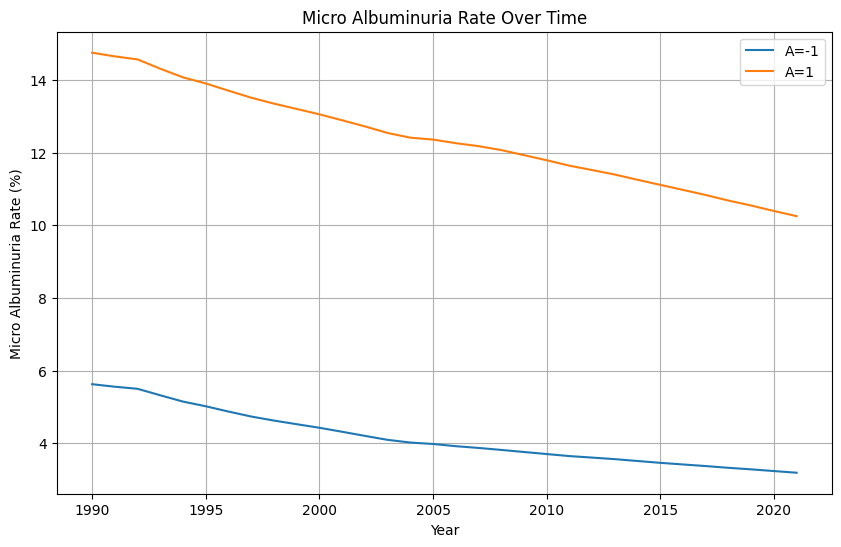

In [155]:

# Calculate micro albuminuria rates over time for each A value
micro_result_ls = []
years = list(range(1990, 2022))

for A_idx, A in [(0,-1), (1,1)]:
    micro_results_A = []
    for k in range(-33,-1):
        total_counts = 0
        total_micro_counts = 0 
        total_healthy_counts = 0

        for i in range(8):
            # Get age counts from age matrix for this ethnicity
            age_counts = np.zeros(75-18)  # Vector to store counts for ages 18-74
            
            # Create dictionary to count ages
            age_dict = {}
            for age_val in age_matrix_vec[i][:,-k]:
                age_dict[age_val] = age_dict.get(age_val, 0) + 1
            
            # Convert dictionary counts to vector
            for age in range(18, 75):
                age_counts[age-18] = age_dict.get(age, 0)
            
            # Get micro albuminuria and healthy rates for this ethnicity
            micro_rates = micro_albu[i,A_idx]
            healthy_rates = healthy_prob[i,A_idx,:]
            
            micro_counts = micro_rates * age_counts[2:]
            healthy_counts = healthy_rates * age_counts[2:]
            
            total_micro_counts += np.sum(micro_counts)
            total_healthy_counts += np.sum(healthy_counts)
            total_healthy_counts += np.sum(age_counts[:2])
            total_counts += np.sum(age_counts)

        micro_result = total_micro_counts / total_counts * 100
        micro_results_A.append(micro_result)
        #micro_results_A = micro_results_A[::-1]
    
    micro_result_ls.append(micro_results_A)



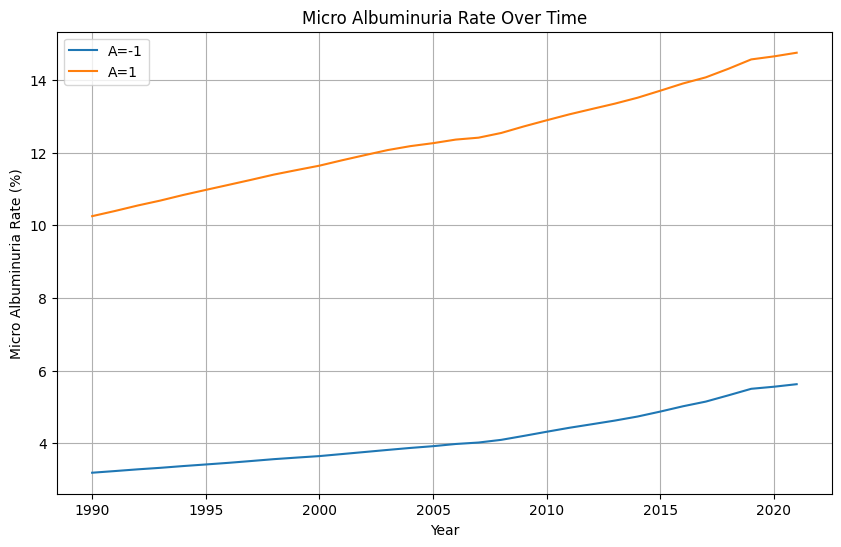

In [255]:
# Plot results
plt.figure(figsize=(10,6))
for A_idx, A in enumerate([-1,1]):
    plt.plot(years, micro_result_ls[A_idx][::-1], label=f'A={A}')
plt.xlabel('Year')
plt.ylabel('Micro Albuminuria Rate (%)')
plt.title('Micro Albuminuria Rate Over Time')
plt.legend()
plt.grid(True)
plt.show()

# the initial stage is age 20 

### stage 20 


In [93]:
np.round(prob_matrix_age_90, decimals=4)

array([[[[0.0009, 0.0009, 0.0009, ..., 0.0099, 0.0099, 0.0099],
         [0.0045, 0.0045, 0.0045, ..., 0.0135, 0.0135, 0.0135]],

        [[0.0011, 0.0011, 0.0011, ..., 0.0121, 0.0121, 0.0121],
         [0.0055, 0.0055, 0.0055, ..., 0.0165, 0.0165, 0.0165]],

        [[0.0021, 0.0021, 0.0021, ..., 0.0231, 0.0231, 0.0231],
         [0.0105, 0.0105, 0.0105, ..., 0.0315, 0.0315, 0.0315]],

        ...,

        [[0.0013, 0.0013, 0.0013, ..., 0.0143, 0.0143, 0.0143],
         [0.0065, 0.0065, 0.0065, ..., 0.0195, 0.0195, 0.0195]],

        [[0.0018, 0.0018, 0.0018, ..., 0.02  , 0.02  , 0.02  ],
         [0.0091, 0.0091, 0.0091, ..., 0.0273, 0.0273, 0.0273]],

        [[0.0014, 0.0014, 0.0014, ..., 0.0154, 0.0154, 0.0154],
         [0.007 , 0.007 , 0.007 , ..., 0.021 , 0.021 , 0.021 ]]],


       [[[0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
         [0.    , 0.    , 0.    , ..., 0.0007, 0.0007, 0.0007]],

        [[0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
         [

In [204]:
# Calculate probability of staying healthy (state a)

# Calculate probability of staying healthy
# Initialize probability matrices
healthy_prob = np.zeros((8, 2, 55))  # Shape: 8 groups x 2 A values x 55 ages
micro_albu = np.zeros((8, 2, 55))    # Shape: 8 groups x 2 A values x 55 ages

# Calculate probabilities for all groups
for idx in range(8):
    for A_idx, A in enumerate(A_range):
        for age_idx in range(55):  # age 20 to 74
            transition_prob = prob_matrix_age_90[0, idx, A_idx, age_idx]  # a → b
            
            if age_idx == 0:
                # For age 20, just use initial probability of staying healthy
                healthy_prob[idx, A_idx, age_idx] = 1 - transition_prob
            else:
                # For subsequent ages, multiply previous probability by probability of staying healthy
                healthy_prob[idx, A_idx, age_idx] = healthy_prob[idx, A_idx, age_idx-1] * (1 - transition_prob)

# Calculate probability of being in microalbuminuria (state b)
for idx in range(8):
    for A_idx, A in enumerate(A_range):
        prob_in_b = 0.0
        for age_idx in range(55):  # age 20 to 74
            if age_idx == 0:
                # For age 20, just use initial transition probability
                inflow = prob_matrix_age_90[0, idx, A_idx, age_idx]
            else:
                # Inflow from a → b in current age
                inflow = healthy_prob[idx, A_idx, age_idx-1] * prob_matrix_age_90[0, idx, A_idx, age_idx]
            
            # Surviving from previous b state (did not go to c)
            prob_in_b = prob_in_b * (1 - prob_matrix_age_90[1, idx, A_idx, age_idx]) + inflow
            
            # Store result
            micro_albu[idx, A_idx, age_idx] = prob_in_b



# Calculate micro albuminuria and healthy rates for each ethnicity and A value
for A_idx, A in [(0,-1), (1,1)]:
    total_counts = 0
    total_micro_counts = 0 
    total_healthy_counts = 0

    for i in range(8):
        # Get age counts from age matrix for this ethnicity
        age_counts = np.zeros(75-18)  # Vector to store counts for ages 18-74
        
        # Create dictionary to count ages
        age_dict = {}
        for age_val in age_matrix_vec[i][:,-2]:
            age_dict[age_val] = age_dict.get(age_val, 0) + 1
        
        # Convert dictionary counts to vector
        for age in range(18, 75):
            age_counts[age-18] = age_dict.get(age, 0)
        
        # Get micro albuminuria and healthy rates for this ethnicity
        micro_rates = micro_albu[i,A_idx]
        healthy_rates = healthy_prob[i,A_idx,:]
        
        micro_counts = micro_rates * age_counts[2:]
        healthy_counts = healthy_rates * age_counts[2:]
        healthy_counts += np.sum(age_counts[:2])
        
        total_micro_counts += np.sum(micro_counts)
        total_healthy_counts += np.sum(healthy_counts)
        total_counts += np.sum(age_counts)

    micro_result = total_micro_counts / total_counts * 100
    healthy_result = total_healthy_counts / total_counts * 100
    macro_result = 100 - micro_result - healthy_result

    print(f"\nResults for A = {A}:")
    print(f"Total micro albuminuria rate: {micro_result:.2f}%")
    print(f"Total healthy rate: {healthy_result:.2f}%") 
    print(f"Total macro albuminuria rate: {macro_result:.2f}%")



Results for A = -1:
Total micro albuminuria rate: 6.28%
Total healthy rate: 235.87%
Total macro albuminuria rate: -142.15%

Results for A = 1:
Total micro albuminuria rate: 16.95%
Total healthy rate: 225.20%
Total macro albuminuria rate: -142.15%


In [ ]:
## save the results 
import numpy as np

# Initialize a list of 8, each will contain a (5, matrix.shape) 3D matrix
albu_1_mat_storage = [None] * 8  

cols = age_matrix_vec[0].shape[1]

for idx in range(8):  # Loop over the 8 groups
    rows = age_matrix_vec[idx].shape[0]
    
    # Create a 3D matrix to store results for all 5 age thresholds (30-34)
    albu_1_mat_3d = np.zeros((21, rows, cols), dtype=int) 

    eth = map_eth(idx)
    gen = idx % 2
    x = 20
    #for A_index, A_actual in enumerate(np.arange(0.003, 0.0072, 0.0002)):  # Loop over the 5 age thresholds
    for A_idx, A_actual in enumerate(A_range):    
        matrix = age_matrix_vec[idx]
        #mask = (matrix >= x) & (matrix <= 74)
        transition_matrix = np.zeros_like(matrix, dtype=float)

        transition_matrix = logistic_function(matrix[mask],A_actual) # * coef[idx]

        random_matrix = np.random.rand(*matrix.shape)
        comparison_matrix = random_matrix < transition_matrix 

        albu_1_mat = np.zeros_like(matrix, dtype=int)  

        for i in range(rows):
            first_one_index = np.argmax(comparison_matrix[i, :])
            if comparison_matrix[i, first_one_index]:
                albu_1_mat[i, first_one_index:cols] = 1  

        death_mask = (matrix == -1)
        albu_1_mat[death_mask] = -1

        # Transition from state 1 to state 2
        state_1 = (albu_1_mat == 1) & (matrix <= 80)
        albu_1_mat[state_1] = np.where(
            np.random.rand(np.sum(state_1)) < result[gen, eth, matrix[state_1] - 26, 2], 
            2, 
            1
        )
        
        for j in range(rows):
            first_2_idx = np.argmax(albu_1_mat[j, :] == 2)
            if albu_1_mat[j, first_2_idx] != 2:
                continue
            else:
                albu_1_mat[j, first_2_idx:cols] = 2  

        albu_1_mat[death_mask] = -1

        # Remove ages outside the range 18–74
        condition = ((matrix < 18) & (matrix > 0)) | (matrix > 74)
        albu_1_mat[condition] = 3  

        # Store in the 3D matrix
        albu_1_mat_3d[A_index] = albu_1_mat  

    # Store the 3D matrix in the list
    albu_1_mat_storage[idx] = albu_1_mat_3d  

# Convert list elements to NumPy arrays
albu_1_mat_storage = [np.array(mat) for mat in albu_1_mat_storage]

# Accessing example:
# albu_1_mat_storage[idx][x_index, :, :] → Matrix for group `idx` at `x=30 + x_index`
idx = 2  # Third group
A_index = 3  # Corresponding to age x=33
print(f"Shape of stored matrix for idx={idx}, x={30 + A_index}: {albu_1_mat_storage[idx][A_index].shape}")


## validation

In [ ]:
# Simulate Markov chains for idx=0 and first A value
idx = 0
A_idx = 0
n_simulations = 100000
n_steps = 4

# Arrays to store simulation results
states = np.zeros((n_simulations, n_steps))  # 0=healthy, 1=micro_albu
state_a_counts = np.zeros(n_steps)
state_b_counts = np.zeros(n_steps)

# Run simulations
for sim in range(n_simulations):
    current_state = 0  # Start in healthy state
    
    for step in range(n_steps):
        if current_state == 0:  # In healthy state
            # Probability of transitioning to microalbuminuria
            p_transition = prob_matrix_age_90[0, idx, A_idx, step]
            if np.random.random() < p_transition:
                current_state = 1  # Moved to next stage
        else:  # In microalbuminuria state
            # Probability of transitioning to next stage
            p_transition = prob_matrix_age_90[1, idx, A_idx, step]
            if np.random.random() < p_transition:
                current_state = 2  # Moved to next stage
        
        states[sim, step] = current_state
        
# Calculate probabilities from simulation
for step in range(n_steps):
    state_a_counts[step] = np.sum(states[:, step] == 0) / n_simulations
    state_b_counts[step] = np.sum(states[:, step] == 1) / n_simulations

print("Simulated probabilities:")
print("State a (healthy):", state_a_counts)
print("State b (microalbuminuria):", state_b_counts)

Simulated probabilities:
State a (healthy): [0.99891 0.99807 0.99715 0.99615]
State b (microalbuminuria): [0.00109 0.00193 0.00285 0.00385]


In [110]:
healthy_prob[0,0,:]

array([0.9991    , 0.99820081, 0.99730243, 0.99640486, 0.99550809,
       0.99461214, 0.99371698, 0.99282264, 0.9919291 , 0.99103636,
       0.99014443, 0.9892533 , 0.98836297, 0.98747345, 0.98658472,
       0.98569679, 0.98480967, 0.98392334, 0.9830378 , 0.98215307,
       0.98126913, 0.98038597, 0.97950358, 0.97862193, 0.97774092,
       0.97686029, 0.97597941, 0.97509664, 0.97420771, 0.97330169,
       0.97235058, 0.97128398, 0.96993182, 0.96792311, 0.96462253,
       0.95941357, 0.95232347, 0.94401061, 0.93512949, 0.92605586,
       0.9169594 , 0.90790902, 0.89893128, 0.89003591, 0.8812261 ,
       0.87250256, 0.86386501, 0.85531283, 0.84684527, 0.83846151,
       0.83016075, 0.82194216, 0.81380493, 0.80574827, 0.79777136])

In [111]:
micro_albu[0,0].shape

(55,)

In [ ]:
# once we have prob;
# we can use prob and population strucutre 


## wtih ethnicities 

In [306]:
# Calculate micro albuminuria and healthy rates for each ethnicity and A value
for A_idx, A in [(0,-1), (1,1)]:
    total_counts = 0
    total_micro_counts = 0 
    total_healthy_counts = 0

    for i in range(8):
        # Get age counts from age matrix for this ethnicity
        age_counts = np.zeros(75-18)  # Vector to store counts for ages 18-74
        
        # Create dictionary to count ages
        age_dict = {}
        for age_val in age_matrix_vec[i][:,-2]:
            age_dict[age_val] = age_dict.get(age_val, 0) + 1
        
        # Convert dictionary counts to vector
        for age in range(18, 75):
            age_counts[age-18] = age_dict.get(age, 0)
        
        # Get micro albuminuria and healthy rates for this ethnicity
        micro_rates = micro_albu[i,A_idx]
        healthy_rates = healthy_prob[i,A_idx,:]
        
        micro_counts = micro_rates * age_counts[2:]
        healthy_counts = healthy_rates * age_counts[2:]
        
        total_micro_counts += np.sum(micro_counts)
        total_healthy_counts += np.sum(healthy_counts)
        total_counts += np.sum(age_counts)

    micro_result = total_micro_counts / total_counts * 100
    healthy_result = total_healthy_counts / total_counts * 100
    macro_result = 100 - micro_result - healthy_result

    print(f"\nResults for A = {A}:")
    print(f"Total micro albuminuria rate: {micro_result:.2f}%")
    print(f"Total healthy rate: {healthy_result:.2f}%") 
    print(f"Total macro albuminuria rate: {macro_result:.2f}%")
   


Results for A = -1:
Total micro albuminuria rate: 5.41%
Total healthy rate: 91.14%
Total macro albuminuria rate: 3.45%

Results for A = 1:
Total micro albuminuria rate: 14.17%
Total healthy rate: 80.59%
Total macro albuminuria rate: 5.24%
